# 03. Stationarity, Autocorrelation, and Features

This is the analytical core of the project.

Notebook 02 showed by eye that the price series wanders with no level it returns to. Here we
establish that formally, and then ask the question everything else depends on:

> **Is there any exploitable structure in NFLX daily returns?**

The answer determines whether the LSTM in notebook 05 has anything to learn. If returns are
serially uncorrelated, then no model given only past prices can beat a naive forecast by much,
and any model that appears to has almost certainly been evaluated badly.

Method ported from andreshg's *TimeSeries Analysis: A Complete Guide*.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

from src import config, plots
from src.data import load_prices
from src.features import daily_returns, log_returns, build_feature_matrix
from src.diagnostics import adf_test, kpss_test, stationarity_report, ljung_box

plots.use_project_style()

nflx = load_prices(config.TICKER).iloc[:-1]   # drop any partial session
close = nflx["Close"]
log_price = np.log(close).rename("log_price")
lret = log_returns(close)
ret = daily_returns(close)

print(f"{len(close):,} sessions  |  {close.index.min().date()} -> {close.index.max().date()}")

2,936 sessions  |  2015-01-02 -> 2026-09-04


---
## 1. Is the timeline well formed?

Before testing anything, check the index is chronological and that gaps are the ones we expect.

In [2]:
gaps = close.index.to_series().diff().dt.days.dropna()

print("monotonic increasing:", close.index.is_monotonic_increasing)
print("duplicate dates:     ", int(close.index.duplicated().sum()))
print()
print("gap between consecutive rows (calendar days):")
print(gaps.value_counts().sort_index().to_string())

monotonic increasing: True
duplicate dates:      0

gap between consecutive rows (calendar days):
Date
1.0    2298
2.0      28
3.0     527
4.0      82


Most gaps are 1 day; a large block are 3 days (Friday to Monday); the rest are holidays.

**We deliberately do not reindex to a continuous calendar.** Filling weekends with interpolated
prices would invent trading that never happened and mechanically damp the volatility we measured
in notebook 02. The market calendar is the correct index for market data. The gaps are real
information, not missing data.

---
## 2. Stationarity

A stationary series has a constant mean, constant variance, and an autocovariance that depends
only on the distance between two points, not on where they sit in time. Nearly every classical
time series model assumes it, and the assumption is not optional. Fit ARIMA to a non-stationary
series and the parameter estimates are not trustworthy.

Look at the three candidate series first.

saved -> reports/figures/03_stationarity_visual.png


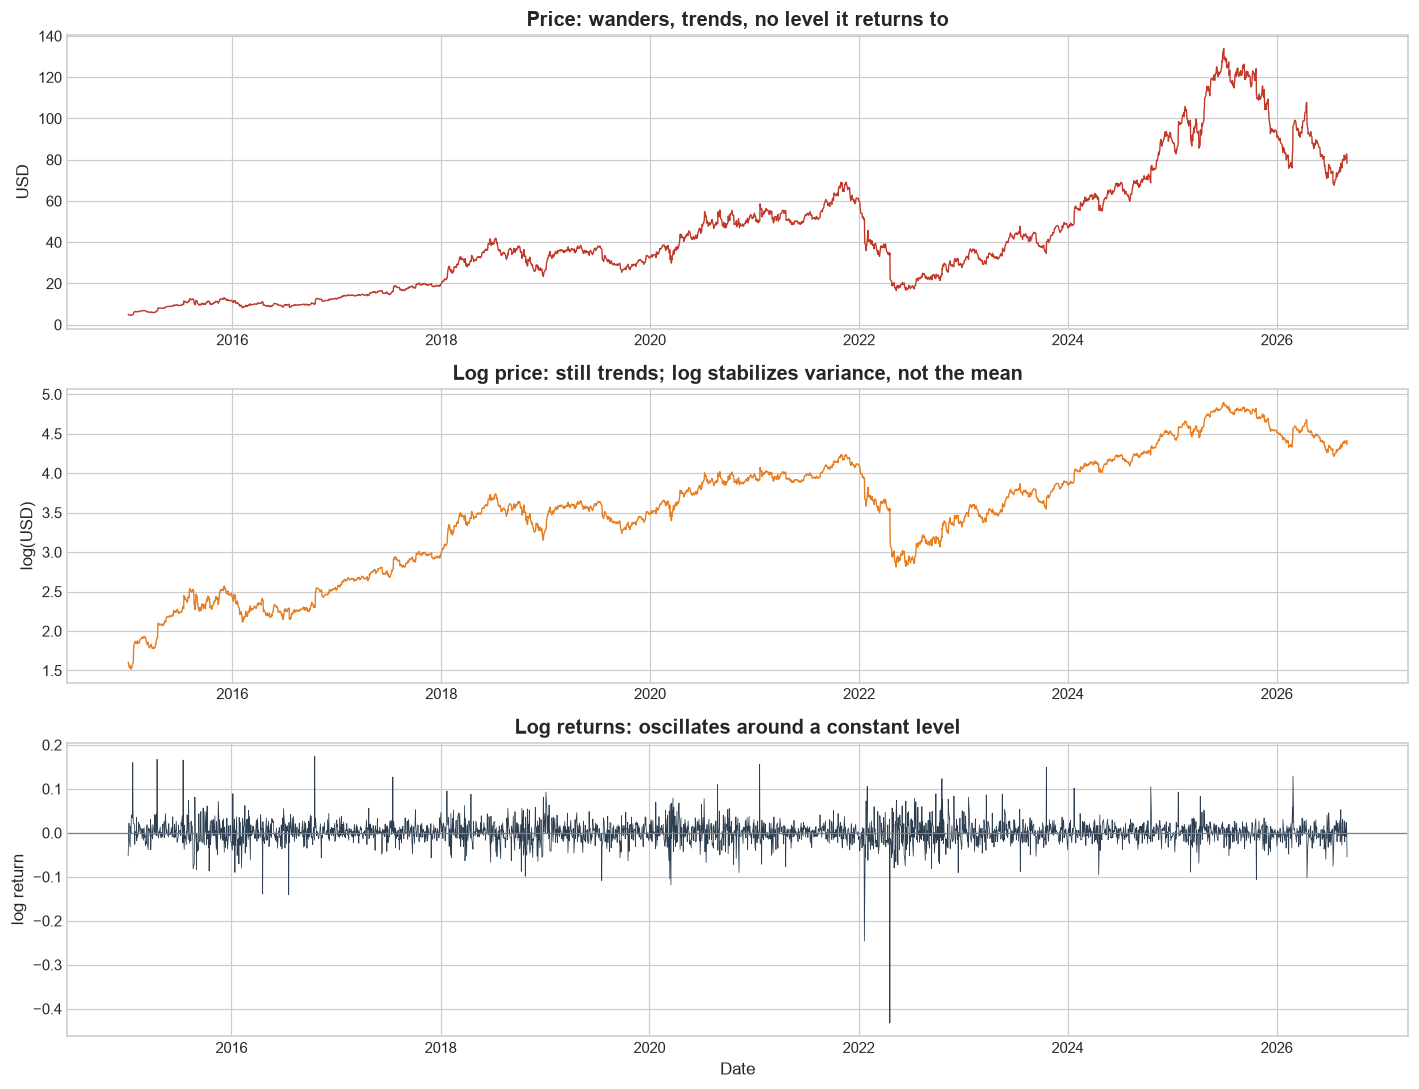

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(close.index, close, linewidth=0.9, color="#c0392b")
axes[0].set_title("Price: wanders, trends, no level it returns to")
axes[0].set_ylabel("USD")

axes[1].plot(log_price.index, log_price, linewidth=0.9, color="#e67e22")
axes[1].set_title("Log price: still trends; log stabilizes variance, not the mean")
axes[1].set_ylabel("log(USD)")

axes[2].plot(lret.index, lret, linewidth=0.5, color="#2c3e50")
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set_title("Log returns: oscillates around a constant level")
axes[2].set_ylabel("log return")
axes[2].set_xlabel("Date")

plt.tight_layout()
plots.save(fig, "03_stationarity_visual")
plt.show()

### The formal tests

Two tests with **opposite null hypotheses**, which is why running both is worth the effort:

| | Null hypothesis | Small p-value means |
|---|---|---|
| **ADF** | series has a unit root (non-stationary) | reject → **stationary** |
| **KPSS** | series is stationary | reject → **non-stationary** |

If they agree, the conclusion is strong. If they disagree, that is itself informative, usually a
sign of a trend-stationary series or a borderline case.

In [4]:
adf = adf_test(close, "Close")
for k, v in adf.items():
    print(f"{k:>18}: {v}")

            series: Close
              test: ADF
   null_hypothesis: has unit root (non-stationary)
         statistic: -1.1406
           p_value: 0.698622
         lags_used: 0
         crit_5pct: -2.8625
       reject_null: False
        conclusion: NON-stationary


p = 0.70, far above 0.05. We **cannot reject** the unit-root null: the price series is
non-stationary. The test statistic is nowhere near the 5% critical value.

In [5]:
adf_r = adf_test(lret, "Log returns")
for k, v in adf_r.items():
    print(f"{k:>18}: {v}")

            series: Log returns
              test: ADF
   null_hypothesis: has unit root (non-stationary)
         statistic: -37.0328
           p_value: 0.0
         lags_used: 1
         crit_5pct: -2.8625
       reject_null: True
        conclusion: stationary


p is effectively zero. We reject the unit root decisively: **log returns are stationary**.

Now both tests over all three series at once.

In [6]:
report = stationarity_report({
    "Close (price)": close,
    "Log price": log_price,
    "Log returns": lret,
})
report

,series,ADF p,ADF says,KPSS p,KPSS says,agree
0,Close (price),0.698622,NON-stationary,0.01,NON-stationary,True
1,Log price,0.197990,NON-stationary,0.01,NON-stationary,True
2,Log returns,0.000000,stationary,0.10,stationary,True


**ADF and KPSS agree on all three.** Prices and log prices are non-stationary; log returns are
stationary. Differencing once, which is what taking returns does, is enough. In ARIMA terms,
`d = 1`.

### Seeing it directly

A stationary series has a stable mean and variance through time. Plotting rolling estimates of
both makes the contrast obvious without any test statistic.

saved -> reports/figures/03_rolling_stats.png


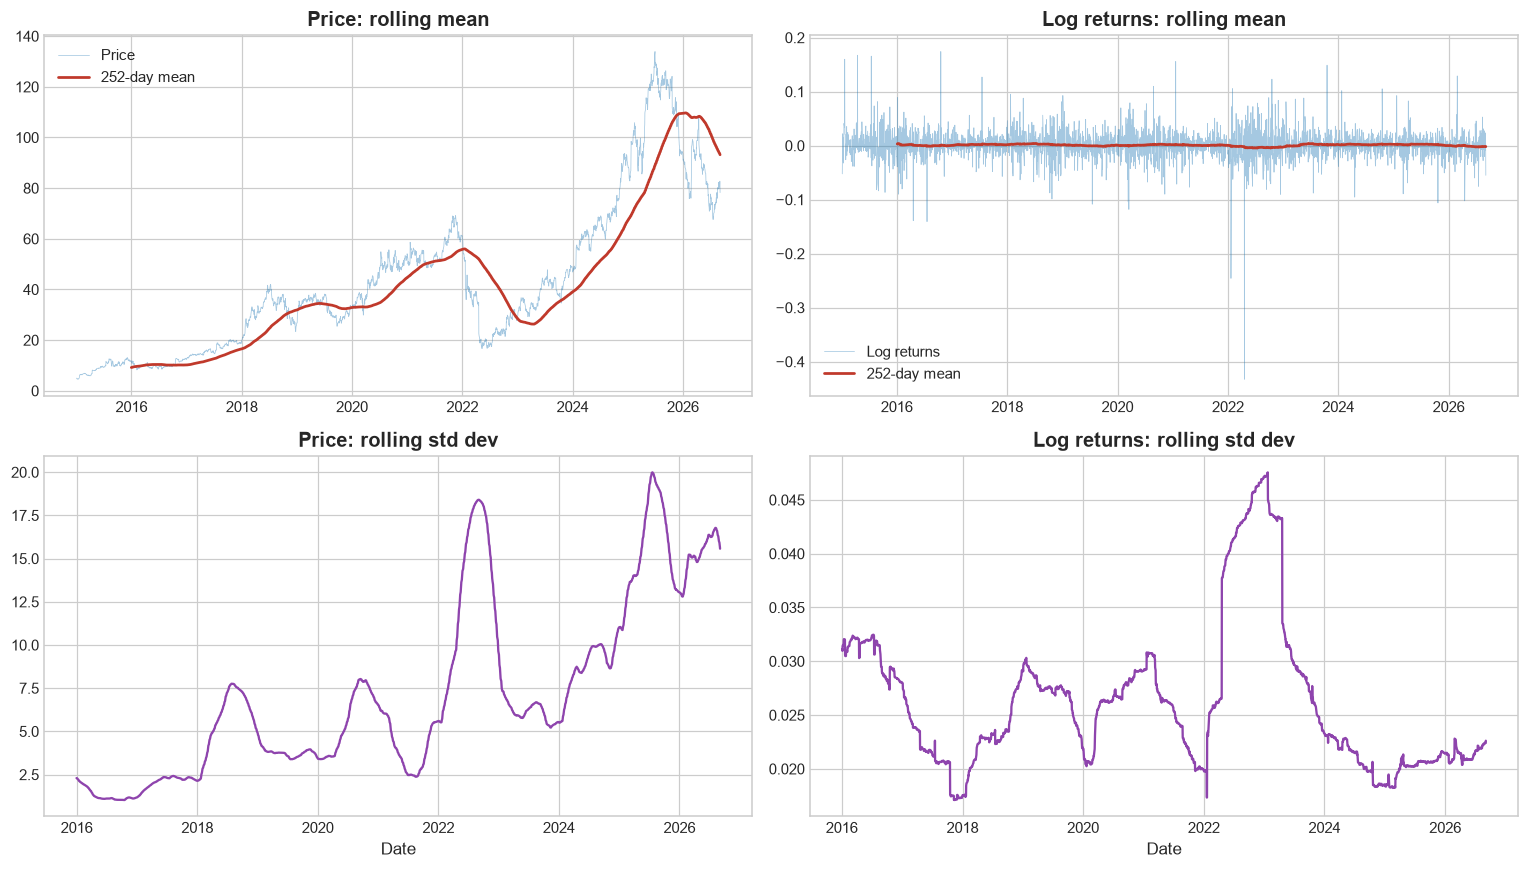

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
window = 252  # one trading year

for col, (series, label) in enumerate([(close, "Price"), (lret, "Log returns")]):
    roll_mean = series.rolling(window).mean()
    roll_std = series.rolling(window).std()

    axes[0, col].plot(series.index, series, linewidth=0.5, alpha=0.4, label=label)
    axes[0, col].plot(roll_mean.index, roll_mean, linewidth=1.8, color="#c0392b",
                      label=f"{window}-day mean")
    axes[0, col].set_title(f"{label}: rolling mean")
    axes[0, col].legend()

    axes[1, col].plot(roll_std.index, roll_std, linewidth=1.5, color="#8e44ad")
    axes[1, col].set_title(f"{label}: rolling std dev")
    axes[1, col].set_xlabel("Date")

plt.tight_layout()
plots.save(fig, "03_rolling_stats")
plt.show()

Left column: the rolling mean of the price climbs from near zero to over one hundred. That alone
disqualifies it as stationary.

Right column: the rolling mean of returns sits flat near zero throughout. Its rolling standard
deviation does move around, which is the volatility clustering from notebook 02, so returns are
not *strictly* stationary either. They are stationary in mean, which is what the models here
require, and the moving variance is a known limitation to state rather than hide.

---
## 3. Why this makes the naive baseline so hard to beat

This is the argument the whole project turns on, so it is worth stating carefully.

A unit root means the series is a **random walk with drift**:

$$P_t = P_{t-1} + \mu + \varepsilon_t$$

If that is the true process, then the best possible forecast of tomorrow's price given everything
knowable today is:

$$\hat{P}_{t+1} = P_t + \mu$$

which is the naive baseline, plus a small drift term. Not *a* reasonable baseline, but the
theoretically optimal one, if the random walk holds.

So a model that "beats" the naive forecast is claiming the random walk does **not** hold for NFLX.
That is a strong claim, and it needs strong evidence: an out-of-sample margin, on splits chosen in
advance, that survives walk-forward validation. A pretty chart is not evidence.

---
## 4. Decomposition

The source notebook decomposes its series into trend, seasonal and residual components. Applying
the same tool here is instructive largely for what it *fails* to find.

saved -> reports/figures/03_decomposition.png


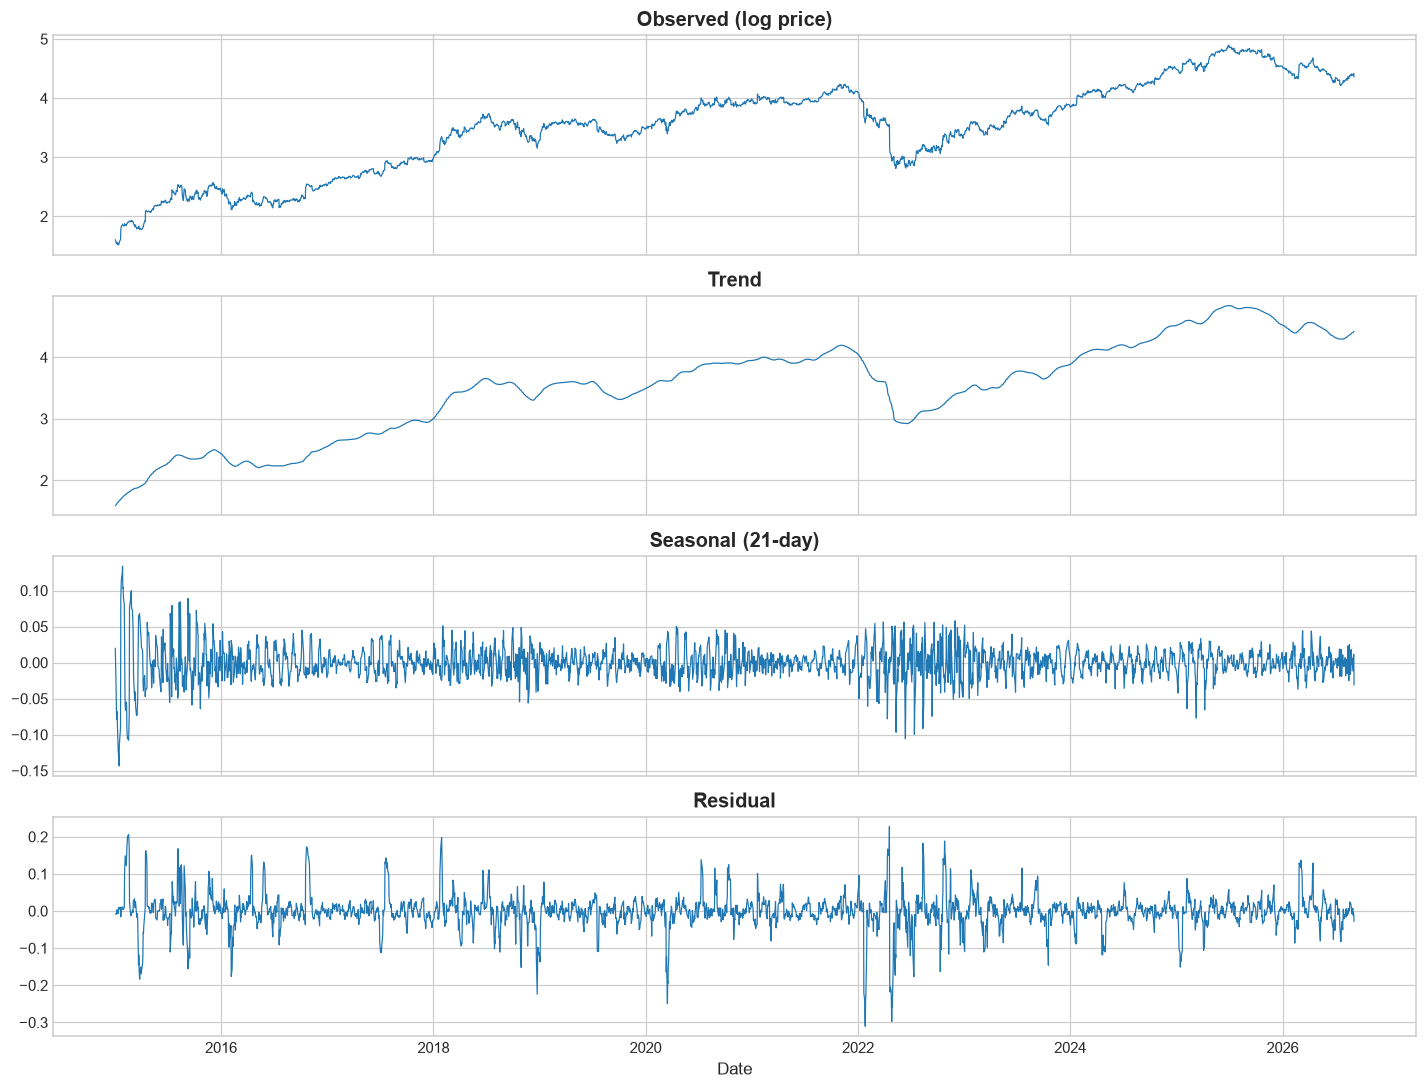

seasonal component std / observed std = 0.0289  (2.89%)


In [8]:
stl = STL(log_price, period=21, robust=True).fit()   # 21 sessions ~ one trading month

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, (series, title) in zip(axes, [
    (stl.observed, "Observed (log price)"),
    (stl.trend, "Trend"),
    (stl.seasonal, "Seasonal (21-day)"),
    (stl.resid, "Residual"),
]):
    ax.plot(series.index, series, linewidth=0.8)
    ax.set_title(title)
axes[-1].set_xlabel("Date")

plt.tight_layout()
plots.save(fig, "03_decomposition")
plt.show()

share = stl.seasonal.std() / stl.observed.std()
print(f"seasonal component std / observed std = {share:.4f}  ({share*100:.2f}%)")

The seasonal component is negligible, a rounding error against the trend.

That is the correct result, and it is worth stating rather than skipping. Groundwater levels,
retail sales and electricity demand have genuine calendar seasonality. **Equity prices do not**,
at least not at a monthly period on a liquid large-cap. If a repeatable monthly price cycle
existed in NFLX, it would be arbitraged away.

Decomposition is a tool for series with seasonal structure. Reporting that a series has none is a
finding, not a failed step.

---
## 5. Autocorrelation, the decisive question

ACF measures correlation between the series and its own past at each lag. PACF measures the same
after removing the effect of shorter lags. Together they are how ARIMA orders are chosen
classically: `q` from where the ACF cuts off, `p` from where the PACF cuts off.

saved -> reports/figures/03_acf_pacf_returns.png


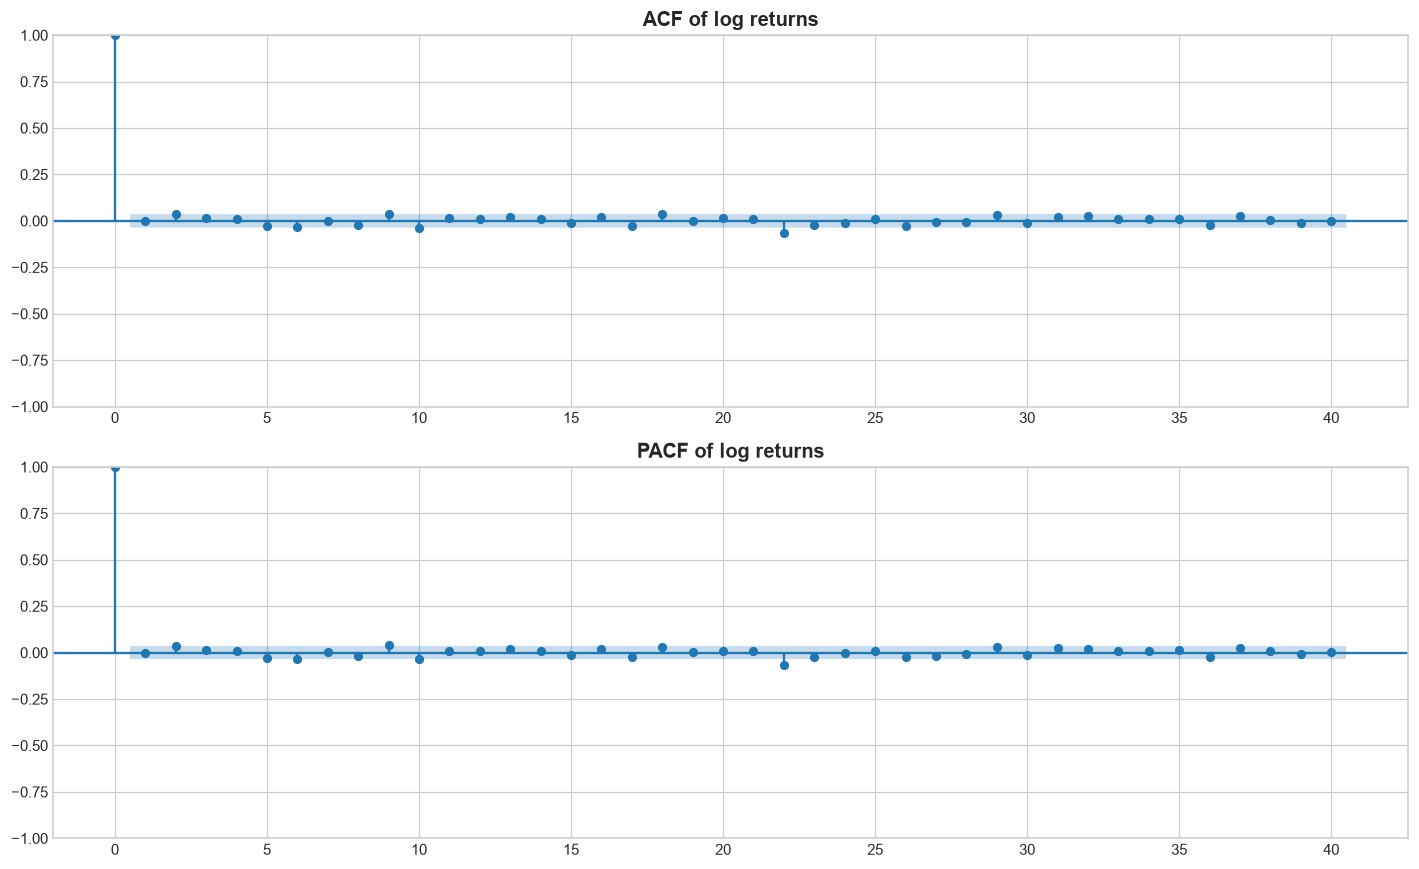

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
plot_acf(lret.dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF of log returns")
plot_pacf(lret.dropna(), lags=40, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF of log returns")
plt.tight_layout()
plots.save(fig, "03_acf_pacf_returns")
plt.show()

Almost every bar sits inside the shaded confidence band, meaning indistinguishable from zero.
There is no clear cut-off to read an order from, because there is essentially no autocorrelation
to model.

The formal version:

In [10]:
lb = ljung_box(ret)
print("Ljung-Box on RETURNS  (null: no autocorrelation)")
print(lb[["statistic", "p_value", "autocorrelated"]].to_string())

Ljung-Box on RETURNS  (null: no autocorrelation)
     statistic   p_value  autocorrelated
lag                                     
1     0.036233  0.849035           False
5     7.507346  0.185558           False
10   19.936162  0.029862            True
21   29.842076  0.095208           False


At lag 1, p = 0.85. Yesterday's return tells us essentially nothing about today's.

Lag 10 sneaks under 0.05, but that is one marginal result among several tests on the same data,
and it is not the kind of effect that survives out-of-sample. It is not something to build on.

### Now the same test on *absolute* returns

Ljung-Box on |RETURNS|  (magnitude, ignoring direction)
      statistic  p_value  autocorrelated
lag                                     
1     34.832411      0.0            True
5    169.725532      0.0            True
10   261.504100      0.0            True
21   430.155364      0.0            True
saved -> reports/figures/03_acf_abs_returns.png


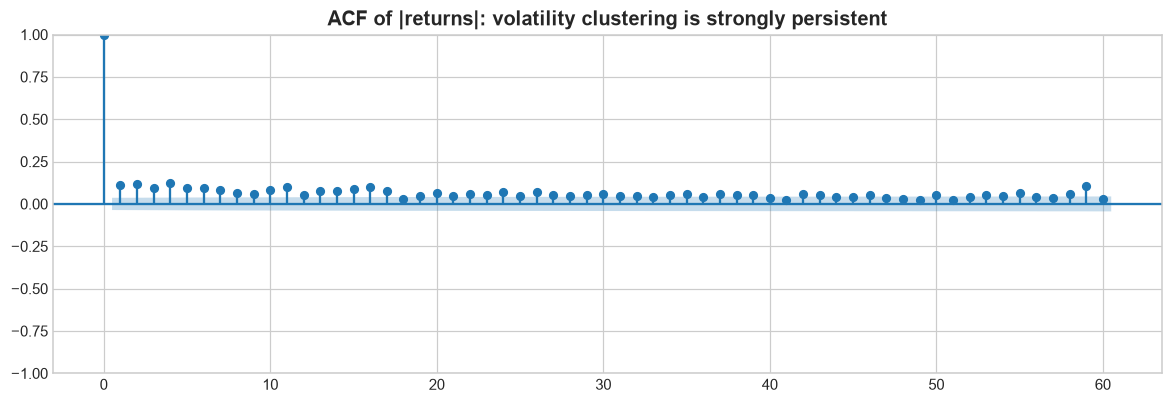

In [11]:
lb_abs = ljung_box(ret.abs())
print("Ljung-Box on |RETURNS|  (magnitude, ignoring direction)")
print(lb_abs[["statistic", "p_value", "autocorrelated"]].to_string())

fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(ret.abs().dropna(), lags=60, ax=ax, alpha=0.05)
ax.set_title("ACF of |returns|: volatility clustering is strongly persistent")
plots.save(fig, "03_acf_abs_returns")
plt.show()

## The central finding

The two tests above are the most important output of this notebook:

| Series | Ljung-Box p at lag 1 | Interpretation |
|---|---|---|
| Returns (direction included) | **0.85** | no detectable structure |
| Absolute returns (magnitude only) | **0.00** | strong, persistent structure |

**Direction is unpredictable. Magnitude is highly predictable.**

Tomorrow's *move size* is forecastable from today, since big days cluster with big days, and the ACF of
absolute returns stays significant out past sixty lags. Tomorrow's *direction* is not.

This is precisely why the standard project design fails while looking like it succeeds. An LSTM
trained on prices with an MSE loss is rewarded for tracking the level, which the random walk hands
it for free, and it is never asked the question it cannot answer. Notebook 05 asks it directly,
via directional accuracy.

It also points at the honest version of this problem: **forecasting volatility** (GARCH and its
relatives) is a tractable task on exactly this data. That is out of scope here, but it is the
right next project.

---
## 6. Candidate ARIMA orders

`d = 1` is settled: one difference makes the series stationary, and returns *are* that difference.

For `p` and `q` the ACF and PACF give no clear signal, which is itself the answer. The best
model in this family is likely to be close to ARIMA(0,1,0), which **is** the random walk, which
**is** the naive baseline. Notebook 04 fits a small grid anyway and lets the information criteria
decide rather than assuming.

In [12]:
candidates = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 2), (5, 1, 0)]
print("Candidate (p, d, q) orders for notebook 04:")
for order in candidates:
    note = "  <- random walk / naive baseline" if order == (0, 1, 0) else ""
    print(f"  ARIMA{order}{note}")

Candidate (p, d, q) orders for notebook 04:
  ARIMA(0, 1, 0)  <- random walk / naive baseline
  ARIMA(1, 1, 0)
  ARIMA(0, 1, 1)
  ARIMA(1, 1, 1)
  ARIMA(2, 1, 2)
  ARIMA(5, 1, 0)


---
## 7. The feature matrix

`build_feature_matrix` assembles everything the models in notebooks 04 and 05 will draw on.

The design rule: **every feature uses only information available strictly before the day being
predicted.** Rolling windows and lags look backwards; the target is shifted forwards. Getting this
wrong is the single easiest way to produce an impressive and completely fake result.

In [13]:
features = build_feature_matrix(nflx)
print("shape:", features.shape)
print()
print("columns:")
for col in features.columns:
    print("  ", col)

shape: (2936, 28)

columns:
   Open
   High
   Low
   Close
   Volume
   return
   log_return
   volatility_21d
   volume_ratio
   high_low_range
   MA_10
   MA_20
   MA_50
   close_over_MA_10
   close_over_MA_20
   close_over_MA_50
   return_lag_1
   return_lag_2
   return_lag_3
   return_lag_5
   return_lag_10
   return_lag_21
   dow_sin
   dow_cos
   month_sin
   month_cos
   target_close
   target_return


In [14]:
features[["Close", "return", "volatility_21d", "close_over_MA_20",
          "return_lag_1", "dow_sin", "target_close", "target_return"]].tail(8)

,Close,return,volatility_21d,close_over_MA_20,return_lag_1,dow_sin,target_close,target_return
Date,,,,,,,,
2026-08-26,81.459999,-0.009364,0.320246,0.062794,0.027747,0.587785,79.839996,-0.019887
2026-08-27,79.839996,-0.019887,0.329330,0.037146,-0.009364,-0.587785,81.720001,0.023547
2026-08-28,81.720001,0.023547,0.333718,0.054710,-0.019887,-0.951057,81.050003,-0.008199
2026-08-31,81.050003,-0.008199,0.324793,0.040877,0.023547,0.000000,80.809998,-0.002961
2026-09-01,80.809998,-0.002961,0.320422,0.032993,-0.008199,0.951057,82.730003,0.023760
2026-09-02,82.730003,0.023760,0.326962,0.051802,-0.002961,0.587785,82.669998,-0.000725
2026-09-03,82.669998,-0.000725,0.327557,0.045073,0.023760,-0.587785,78.250000,-0.053466
2026-09-04,78.250000,-0.053466,0.384328,-0.013365,-0.000725,-0.951057,NaN,NaN


### A leakage check

Two properties must hold, and asserting them is cheaper than debugging a suspiciously good model
later:

1. `target_close` on row *t* equals `Close` on row *t+1*.
2. Every feature on row *t* is computable from data up to and including row *t*.

In [15]:
check = features[["Close", "target_close"]].dropna()
shifted_match = np.allclose(
    check["target_close"].values[:-1],
    check["Close"].values[1:],
)
print("target_close(t) == Close(t+1):", shifted_match)

# A lag feature must never anticipate the future.
lag_ok = np.allclose(
    features["return_lag_1"].dropna().values,
    features["return"].shift(1).dropna().values,
)
print("return_lag_1(t) == return(t-1):", lag_ok)

# Rolling volatility at time t must not change if future rows are removed.
cut = 2000
vol_full = features["volatility_21d"].iloc[cut]
vol_truncated = build_feature_matrix(nflx.iloc[: cut + 1])["volatility_21d"].iloc[cut]
print("volatility_21d unaffected by future rows:",
      bool(np.isclose(vol_full, vol_truncated)))

assert shifted_match and lag_ok, "feature/target alignment is broken"
print("\nAll leakage checks passed.")

target_close(t) == Close(t+1): True
return_lag_1(t) == return(t-1): True
volatility_21d unaffected by future rows: True

All leakage checks passed.


In [16]:
features.to_csv(config.DATA_PROCESSED / f"{config.TICKER}_features.csv")
print(f"saved -> data/processed/{config.TICKER}_features.csv  {features.shape}")

saved -> data/processed/NFLX_features.csv  (2936, 28)


---
## What this established

1. **Prices are non-stationary; returns are stationary.** ADF and KPSS agree, which is much
   stronger than either test alone. `d = 1`.
2. **A unit root implies the naive forecast is theoretically optimal** under a random walk. Beating
   it is a strong claim requiring strong out-of-sample evidence.
3. **Returns show no usable autocorrelation** (Ljung-Box p = 0.85 at lag 1), so ARIMA has little
   to work with, and neither does anything else fed only past prices.
4. **Absolute returns are strongly autocorrelated**, with p ≈ 0 at every lag tested, significant past
   60 lags. Volatility is predictable even though direction is not.
5. **No meaningful seasonality**, unlike the reference notebook's dataset. Correctly reported
   rather than skipped.
6. **A leak-free feature matrix**, with the alignment asserted rather than assumed.

**Next:** `04_baselines_and_arima.ipynb`, building the naive, drift, SMA and EMA baselines, fitting the
ARIMA grid, and lock the results table that every later model must beat.